In [ ]:
# Squat Supervised Baseline (R(2+1)D-18, Kinetics-400-V1 init)
#
# Hyperparameters follow Parmar et al. (ECCV 2022), paper §5.
#
# Run in Colab on an L4 GPU (24 GB VRAM). Mounts Drive shortcut
# `My Drive/Fitness-AQA_dataset_release`. Estimated wall-time: 2-4 h best case /
# 6-8 h worst case. Step 3 measures epoch-0 wall time before the full 50-epoch run.
#
# Jupytext "percent" format: each `# %%` marker starts a new cell. Convert via
# `pip install jupytext && jupytext --to ipynb 03_squat_supervised_baseline.py`,
# or paste cells one at a time.

# Squat Supervised Baseline — R(2+1)D-18 (Kinetics-400 init)

Supervised multi-label baseline for two squat form errors (KIE, KFE) on the Fitness-AQA dataset (Parmar et al., ECCV 2022), using an R(2+1)D-18 backbone initialised from Kinetics-400. Trains on the official splits and reports F1 per error against the published Kinetics and MD baselines.

## Setup

Clone the repository and add it to the Python path so the `backend.training.aqa` modules are importable.

In [ ]:
import os
import subprocess
import sys

REPO_DIR = "/content/fitnova"
REPO_URL = "https://github.com/Ibrahim-Shahin1/fitnova.git"
BRANCH = "fresh-start"

if not os.path.isdir(REPO_DIR):
    print(f"Cloning {REPO_URL} (branch {BRANCH}) -> {REPO_DIR} ...")
    subprocess.run(
        ["git", "clone", "-b", BRANCH, REPO_URL, REPO_DIR],
        check=True,
    )
else:
    print(f"Repo already at {REPO_DIR}; pulling latest from origin/{BRANCH} ...")
    subprocess.run(["git", "-C", REPO_DIR, "fetch", "origin", BRANCH], check=True)
    subprocess.run(["git", "-C", REPO_DIR, "checkout", BRANCH], check=True)
    subprocess.run(["git", "-C", REPO_DIR, "pull", "--ff-only", "origin", BRANCH], check=True)

os.chdir(REPO_DIR)
if REPO_DIR not in sys.path:
    sys.path.insert(0, REPO_DIR)

_head = subprocess.run(
    ["git", "-C", REPO_DIR, "rev-parse", "--short", "HEAD"],
    capture_output=True, text=True, check=True,
).stdout.strip()
print(f"\nRepo ready: {REPO_DIR} @ {_head}")
print(f"sys.path[0]: {sys.path[0]}")
print(f"cwd: {os.getcwd()}")

Repo already at /content/fitnova; pulling latest from origin/fresh-start ...

Repo ready: /content/fitnova @ a0841b4
sys.path[0]: /content/fitnova
cwd: /content/fitnova


## Step 0 — environment and GPU check

The next cell must import `_envinit` before `torch`: this sets `CUBLAS_WORKSPACE_CONFIG=:4096:8` before any `import torch` creates the CUDA context, otherwise `torch.use_deterministic_algorithms(True)` raises at runtime. PyAV is installed before the first torchvision import (its `read_video` FFmpeg backend), the GPU is checked for >=22 GB VRAM, Drive is mounted, and the squat videos are staged.

In [ ]:
from backend.training.aqa.harness import _envinit  # sets CUBLAS_WORKSPACE_CONFIG before torch

import importlib.metadata
import os
import subprocess
import sys

# torchvision.io.read_video requires PyAV as its FFmpeg backend on Colab;
# install BEFORE the first torch/torchvision import so the cached `av`
# reference in torchvision.io.video is a real module.
try:
    import av  # noqa: F401
    _pyav_status = "already installed"
except ImportError:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "av"], check=True)
    import av  # noqa: F401
    _pyav_status = "installed by Step 0"
print(f"PyAV {av.__version__} ({_pyav_status})")

# Dependency version probe. No new pip installs.
_PHASE3_DEPS = ["torch", "torchvision", "scikit-learn", "matplotlib", "tqdm", "numpy"]
print("\nDependency versions (supply-chain guard):")
for _pkg in _PHASE3_DEPS:
    try:
        _ver = importlib.metadata.version(_pkg)
        print(f"  {_pkg:<14} {_ver}")
    except importlib.metadata.PackageNotFoundError:
        raise RuntimeError(
            f"Dependency '{_pkg}' is NOT installed. This notebook "
            "introduces zero new pip dependencies — every package is already "
            "in backend/requirements.txt. If this fires, the "
            "Colab runtime is misconfigured."
        )

import torch
import torchvision

print("\npython     :", sys.version.split()[0])
print("torch      :", torch.__version__)
print("torchvision:", torchvision.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUBLAS_WORKSPACE_CONFIG:", os.environ.get("CUBLAS_WORKSPACE_CONFIG"))

# GPU + VRAM check.
assert torch.cuda.is_available(), (
    "GPU required — Runtime > Change runtime type > Hardware accelerator: L4"
)
_gpu_name = torch.cuda.get_device_name(0)
_vram_gb = torch.cuda.get_device_properties(0).total_memory / (1024 ** 3)
print(f"CUDA device : {_gpu_name} ({_vram_gb:.1f} GB VRAM)")
assert "L4" in _gpu_name or _vram_gb >= 22.0, (
    f"Expecting an L4 GPU with >=22 GB VRAM; got {_gpu_name} {_vram_gb:.1f} GB. "
    "Sizing assumes 24 GB headroom for fp32 batch 16 on R(2+1)D-18."
)

# Verify torchvision.io PyAV backend (no real video needed).
from torchvision.io.video import av as _tv_av_ref
assert not isinstance(_tv_av_ref, Exception), (
    "torchvision.io cached `av` as an Exception — PyAV install ordered wrong. "
    "Step 0 must install av BEFORE importing torch/torchvision."
)
print("torchvision.io PyAV backend: ready")

# Drive mount (idempotent — drive.mount no-ops on a second call).
from google.colab import drive
drive.mount('/content/drive')

MYDRIVE = '/content/drive/MyDrive'
ROOT = os.path.join(MYDRIVE, 'Fitness-AQA_dataset_release')
print("\nROOT :", ROOT)
print("exists:", os.path.exists(ROOT))

# Idempotent video staging (cache-hit path).
from backend.training.aqa.harness.colab import stage_squat_videos
VIDEOS_ROOT = stage_squat_videos(MYDRIVE)
from pathlib import Path
_mp4_count = len(list(Path(VIDEOS_ROOT).glob('*.mp4')))
print(f"\nVIDEOS_ROOT: {VIDEOS_ROOT}")
print(f"mp4 count: {_mp4_count} (expected 1739)")
assert _mp4_count == 1739, f"Expected 1739 mp4s, got {_mp4_count}"

PyAV 17.0.1 (already installed)

[T-03-04] Dependency versions (supply-chain guard):
  torch          2.10.0+cu128
  torchvision    0.25.0+cu128
  scikit-learn   1.6.1
  matplotlib     3.10.0
  tqdm           4.67.3
  numpy          2.0.2

python     : 3.12.13
torch      : 2.10.0+cu128
torchvision: 0.25.0+cu128
CUDA available: True
CUBLAS_WORKSPACE_CONFIG: :4096:8
CUDA device : NVIDIA L4 (22.0 GB VRAM)
torchvision.io PyAV backend: ready
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

ROOT : /content/drive/MyDrive/Fitness-AQA_dataset_release
exists: True

VIDEOS_ROOT: /content/squat_videos
mp4 count: 1739 (expected 1739 per Phase 1)


## Step 1 — dataset smoke

Verify the data pipeline: split counts reconcile, `pos_weight` matches the train derivation, and one batch loads with the expected `(B, 3, T, H, W)` clip and `(B, 2)` label shapes.

In [ ]:
from backend.training.aqa.datasets.squat import SquatKIEKFEDataset
from backend.training.aqa.harness.supervised_train import (
    SupervisedConfig,
    _build_dataloaders,
)

config = SupervisedConfig()

train_ds = SquatKIEKFEDataset(
    split="train",
    drive_root=MYDRIVE,
    videos_root=VIDEOS_ROOT,
    num_frames=config.num_frames,
    crop_size=config.crop_size,
    train_aug=True,
    train_jitter_frames=config.train_jitter_frames,
)
val_ds = SquatKIEKFEDataset(
    split="val",
    drive_root=MYDRIVE,
    videos_root=VIDEOS_ROOT,
    num_frames=config.num_frames,
    crop_size=config.crop_size,
    train_aug=False,
    train_jitter_frames=config.train_jitter_frames,
)
test_ds = SquatKIEKFEDataset(
    split="test",
    drive_root=MYDRIVE,
    videos_root=VIDEOS_ROOT,
    num_frames=config.num_frames,
    crop_size=config.crop_size,
    train_aug=False,
    train_jitter_frames=config.train_jitter_frames,
)

print(f"len(train_ds) = {len(train_ds)} (expected 1136)")
print(f"len(val_ds)   = {len(val_ds)} (expected 243)")
print(f"len(test_ds)  = {len(test_ds)} (expected 244)")
assert len(train_ds) == 1136 and len(val_ds) == 243 and len(test_ds) == 244

print(f"\npos_weight (train-derived): {train_ds.pos_weight.tolist()}")
print("                            expected approximately [≈6.10, ≈0.45]")
assert val_ds.pos_weight.tolist() == train_ds.pos_weight.tolist()
assert test_ds.pos_weight.tolist() == train_ds.pos_weight.tolist()

loaders = _build_dataloaders(
    seed=42, config=config, drive_root=MYDRIVE, videos_root=VIDEOS_ROOT,
)
clip, label = next(iter(loaders["train"]))
print(f"\nFirst train batch:")
print(f"  clip.shape  = {tuple(clip.shape)}  (expected ({config.batch_size}, 3, {config.num_frames}, {config.crop_size}, {config.crop_size}))")
print(f"  clip.dtype  = {clip.dtype}")
print(f"  label.shape = {tuple(label.shape)}  (expected ({config.batch_size}, 2))")
print(f"  label.dtype = {label.dtype}")
print(f"  label (KIE/KFE per clip):\n{label}")

import torch
assert tuple(clip.shape) == (
    config.batch_size, 3, config.num_frames, config.crop_size, config.crop_size,
)
assert tuple(label.shape) == (config.batch_size, 2)
assert label.dtype == torch.float32

len(train_ds) = 1136 (expected 1136)
len(val_ds)   = 243 (expected 243)
len(test_ds)  = 244 (expected 244)

pos_weight (train-derived): [6.099999904632568, 0.4526854157447815]
                            expected approximately [≈6.10, ≈0.45]

First train batch:
  clip.shape  = (16, 3, 32, 112, 112)  (expected (16, 3, 32, 112, 112))
  clip.dtype  = torch.float32
  label.shape = (16, 2)  (expected (16, 2))
  label.dtype = torch.float32
  label (KIE/KFE per clip):
tensor([[0., 1.],
        [0., 1.],
        [0., 1.],
        [0., 0.],
        [0., 1.],
        [0., 1.],
        [0., 0.],
        [0., 0.],
        [0., 1.],
        [0., 1.],
        [0., 1.],
        [0., 1.],
        [1., 1.],
        [0., 0.],
        [0., 1.],
        [0., 1.]])


## Step 2 — model construction smoke

Build R(2+1)D-18 with a `Linear(512, 2)` head, run one forward and backward pass on a real batch, and measure peak VRAM to confirm headroom before the full training run.

In [ ]:
import torch  # noqa: F811 — also imported in Step 1; harmless in notebook
from backend.training.aqa.harness.supervised_train import build_model

model = build_model().to("cuda")  # ~120 MB Kinetics-V1 download on first call
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"total_params     = {total_params:_}")
print(f"trainable_params = {trainable_params:_}")
assert trainable_params == total_params
assert 30_000_000 < total_params < 33_000_000

clip, label = next(iter(loaders["train"]))
clip = clip.to("cuda")
label = label.to("cuda")
with torch.no_grad():
    logits = model(clip)
print(f"\nlogits.shape = {tuple(logits.shape)}  (expected (16, 2))")
print(f"logits.dtype = {logits.dtype}")
print(f"logits sample:\n{logits.detach().cpu()}")
assert tuple(logits.shape) == (16, 2)
assert logits.dtype == torch.float32

peak_vram_fwd_gb = torch.cuda.max_memory_allocated() / (1024 ** 3)
print(f"\nPeak VRAM after forward (batch 16, no backward): {peak_vram_fwd_gb:.2f} GB")
torch.cuda.reset_peak_memory_stats()

criterion = torch.nn.BCEWithLogitsLoss(pos_weight=train_ds.pos_weight.to("cuda"))
logits = model(clip)
loss = criterion(logits, label)
loss.backward()
peak_vram_train_gb = torch.cuda.max_memory_allocated() / (1024 ** 3)
print(f"Peak VRAM after backward (batch 16, fp32): {peak_vram_train_gb:.2f} GB")
assert peak_vram_train_gb < 20.0

del model, logits, loss, criterion
torch.cuda.empty_cache()
print("\nGPU freed; ready for Step 3 timing probe.")

Downloading: "https://download.pytorch.org/models/r2plus1d_18-91a641e6.pth" to /root/.cache/torch/hub/checkpoints/r2plus1d_18-91a641e6.pth


100%|██████████| 120M/120M [00:00<00:00, 189MB/s]


total_params     = 31_301_151
trainable_params = 31_301_151

logits.shape = (16, 2)  (expected (16, 2))
logits.dtype = torch.float32
logits sample:
tensor([[-1.1130, -0.1571],
        [-0.9817, -0.6873],
        [-0.6915, -0.3588],
        [-0.8074, -0.1689],
        [-0.7532, -0.2835],
        [-0.7226, -0.2605],
        [-0.6488, -0.5926],
        [-1.0453, -0.5611],
        [-0.7643, -0.1915],
        [-0.8457, -0.8292],
        [-1.0780, -0.3935],
        [-0.7450, -0.8755],
        [-0.1881, -0.3913],
        [-0.6389, -0.1158],
        [-0.6732, -0.3057],
        [-0.6881, -0.6546]])

Peak VRAM after forward (batch 16, no backward): 3.44 GB
Peak VRAM after backward (batch 16, fp32): 15.22 GB

GPU freed; ready for Step 3 timing probe.


## Step 3 — epoch-0 timing probe

One fresh epoch to estimate total training wall time, and a checkpoint round-trip (`torch.load`) to validate the on-disk schema.

In [ ]:
import time
import os

import torch  # noqa: F811 — already imported earlier; harmless in notebook
from backend.training.aqa.harness.supervised_train import (
    SupervisedConfig,
    run_supervised_epoch,
)

timing_config = SupervisedConfig()  # config defaults

TIMING_RUN_NAME = "r2plus1d18_squat_supervised_v1_timing"

t0 = time.perf_counter()
result = run_supervised_epoch(
    run_name=TIMING_RUN_NAME,
    drive_root=MYDRIVE,
    videos_root=VIDEOS_ROOT,
    seed=42,
    config=timing_config,
    resume=False,
    max_epochs=1,
)
wall_time_s = time.perf_counter() - t0

epoch_0_time_s = result["metrics_history"][0]["epoch_wall_time_s"]
estimated_total_h = epoch_0_time_s * timing_config.max_epochs / 3600.0
val_macro_f1_after_1_epoch = result["metrics_history"][0]["val_macro_f1"]

print(f"epoch_0_time_s        = {epoch_0_time_s:.1f} s")
print(f"wall_time_s (outer)   = {wall_time_s:.1f} s")
print(f"max_epochs (config)   = {timing_config.max_epochs}")
print(f"estimated_total_h     = {estimated_total_h:.2f}  ({timing_config.max_epochs} × epoch_0 / 3600)")
print(f"val_macro_f1 (1 epoch)= {val_macro_f1_after_1_epoch:.4f}  (sanity: > 0.3 expected)")

loss_per_batch = result["metrics_history"][0]["train_loss_per_batch"]
n_train_batches = len(loss_per_batch)
n_val_batches = (243 + timing_config.batch_size - 1) // timing_config.batch_size
expected_train_batches = (1136 + timing_config.batch_size - 1) // timing_config.batch_size
print(f"\nTrain batches      : {n_train_batches}  (expected ≈{expected_train_batches})")
print(f"Val batches        : {n_val_batches}")
print(f"Mean per-batch time: {epoch_0_time_s / (n_train_batches + n_val_batches) * 1000:.0f} ms")

ckpt_path = result["checkpoint_path"]
ckpt_size_mb = os.path.getsize(ckpt_path) / (1024 ** 2)
print(f"\nepoch_000.pt path = {ckpt_path}")
print(f"epoch_000.pt size = {ckpt_size_mb:.0f} MB  (expected 300–500 MB)")
assert 300 < ckpt_size_mb < 500

payload = torch.load(ckpt_path, map_location="cpu", weights_only=False)
_required = {
    "epoch", "model_state_dict", "optimizer_state_dict", "scheduler_state_dict",
    "rng_state", "metrics_history", "best_f1_val", "best_thresholds",
    "config_hash", "config_repr", "code_version",
}
_missing = _required - payload.keys()
assert not _missing, f"Checkpoint missing keys: {_missing}"
assert payload["code_version"] == "phase03-supervised-baseline"
print(f"\nCheckpoint schema OK (11 keys; code_version='{payload['code_version']}')")

print("\n" + "=" * 72)
print("Timing estimate:")
print("  estimated_total_h <= 8  -> 50 epochs")
print("  estimated_total_h > 8   -> 15 epochs + early_stop_patience=5")
print("  AMP available but not used (numerical-stability tradeoff)")
print("=" * 72)

epoch_0_time_s        = 320.0 s
wall_time_s (outer)   = 343.2 s
max_epochs (config)   = 50
estimated_total_h     = 4.44  (50 × epoch_0 / 3600)
val_macro_f1 (1 epoch)= 0.5197  (sanity: > 0.3 expected)

Train batches      : 71  (expected ≈71)
Val batches        : 16
Mean per-batch time: 3678 ms

epoch_000.pt path = /content/drive/MyDrive/FitNova/checkpoints/phase03/r2plus1d18_squat_supervised_v1_timing/epoch_000.pt
epoch_000.pt size = 358 MB  (expected 300–500 MB)

Checkpoint schema OK (11 D8 keys; code_version='phase03-supervised-baseline')

DECISION GATE — paste back numbers + pick option-a / -b / -c:
  option-a: estimated_total_h ≤ 8  → proceed with 50 epochs
  option-b: estimated_total_h > 8  → drop to 15 epochs + early_stop_patience=5
  option-c: enable AMP (NOT recommended — RESEARCH §11 conflict)


## Step 4 — full supervised training run

Train to the configured epoch budget, resuming from the latest checkpoint if present. Atomic checkpoint per epoch; `best.pt` is written whenever val macro-F1 improves, with early stopping on plateau.

In [ ]:
!git -C /content/fitnova pull

remote: Enumerating objects: 13, done.
remote: Counting objects: 100% (13/13), done.
remote: Compressing objects: 100% (2/2), done.
remote: Total 7 (delta 5), reused 7 (delta 5), pack-reused 0 (from 0)
Unpacking objects: 100% (7/7), 984 bytes | 492.00 KiB/s, done.
From https://github.com/Ibrahim-Shahin1/fitnova
   5cec2f5..a0841b4  fresh-start -> origin/fresh-start
Updating 5cec2f5..a0841b4
Fast-forward
 backend/training/aqa/harness/supervised_train.py | 8 +++++++-
 1 file changed, 7 insertions(+), 1 deletion(-)


In [ ]:
import os

from backend.training.aqa.harness.supervised_train import (
    SupervisedConfig,
    run_supervised_epoch,
)

config = SupervisedConfig()  # 50 epochs; timing at Step 3 estimated 4.44 h
RUN_NAME = "r2plus1d18_squat_supervised_v1"

print(f"Starting training run: {RUN_NAME}")
print(f"  max_epochs            = {config.max_epochs}")
print(f"  early_stop_patience   = {config.early_stop_patience}")
print(f"  batch_size            = {config.batch_size}")
print(f"  num_workers           = {config.num_workers}")
print(f"  learning_rate         = {config.learning_rate}")
print(f"  weight_decay          = {config.weight_decay}")
print(f"  scheduler             = {config.scheduler_name} (T_max={config.scheduler_t_max})")
print(f"\nDisconnect-safe: the run resumes from latest.txt.\n")

result = run_supervised_epoch(
    run_name=RUN_NAME,
    drive_root=MYDRIVE,
    videos_root=VIDEOS_ROOT,
    seed=42,
    config=config,
    resume=True,
    max_epochs=config.max_epochs,
)

run_dir = os.path.dirname(result["checkpoint_path"])
print("\n" + "=" * 72)
print("Training complete (or stopped early on val-macro-F1 plateau).")
print(f"  Final epoch reached    : {result['epoch']}")
print(f"  best_f1_val (macro)    : {result['best_f1_val']:.4f}")
print(f"  Last checkpoint        : {result['checkpoint_path']}")
print(f"  Best checkpoint        : {result['best_checkpoint_path']}")
print(f"  Run dir                : {run_dir}")
print("=" * 72)

assert os.path.exists(result["best_checkpoint_path"]), result["best_checkpoint_path"]
best_size_mb = os.path.getsize(result["best_checkpoint_path"]) / (1024 ** 2)
print(f"\nbest.pt size: {best_size_mb:.0f} MB")
assert 300 < best_size_mb < 500
assert result["epoch"] >= 5
assert result["best_f1_val"] > 0.5

print("\nPer-epoch metrics history:")
print(f"  {'ep':>3s} {'tr_loss':>8s} {'vl_loss':>8s} {'f1_kie':>7s} {'f1_kfe':>7s} {'macro':>7s} {'time_s':>7s}")
for entry in result["metrics_history"]:
    print(
        f"  {entry['epoch']:>3d} {entry['train_loss_mean']:>8.4f} "
        f"{entry['val_loss_mean']:>8.4f} {entry['val_f1_kie']:>7.4f} "
        f"{entry['val_f1_kfe']:>7.4f} {entry['val_macro_f1']:>7.4f} "
        f"{entry['epoch_wall_time_s']:>7.1f}"
    )

Starting Phase 3 production run: r2plus1d18_squat_supervised_v1
  max_epochs            = 50
  early_stop_patience   = 8
  batch_size            = 16
  num_workers           = 4
  learning_rate         = 0.0001
  weight_decay          = 0.0
  scheduler             = cosine (T_max=50)

Disconnect-safe: re-run Cell A → Step 0 → Step 4 to resume from latest.txt.




Phase 3 training complete (or stopped early on val-macro-F1 plateau).
  Final epoch reached    : 11
  best_f1_val (macro)    : 0.5454
  Last checkpoint        : /content/drive/MyDrive/FitNova/checkpoints/phase03/r2plus1d18_squat_supervised_v1/epoch_011.pt
  Best checkpoint        : /content/drive/MyDrive/FitNova/checkpoints/phase03/r2plus1d18_squat_supervised_v1/best.pt
  Run dir                : /content/drive/MyDrive/FitNova/checkpoints/phase03/r2plus1d18_squat_supervised_v1

best.pt size: 358 MB

Per-epoch metrics history:
   ep  tr_loss  vl_loss  f1_kie  f1_kfe   macro  time_s
    0   0.8325   0.8107  0.3313  0.7081  0.5197   321.8
    1   0.5711   1.2105  0.3043  0.7771  0.5407   323.6
    2   0.3929   1.2718  0.2828  0.7493  0.5161   328.0
    3   0.2469   1.2708  0.2970  0.7937  0.5454   326.1
    4   0.2299   1.5994  0.2822  0.7527  0.5175   336.7
    5   0.1682   1.2828  0.2957  0.7625  0.5291   330.8
    6   0.1083   1.6283  0.2989  0.7658  0.5323   370.5
    7   0.0767   1.

## Step 5 — threshold sweep on val

Per-error F1-maximising threshold selection via `sklearn.precision_recall_curve`, persisted as `best_thresholds = {"kie", "kfe"}` into `best.pt`.

In [ ]:
import os

import numpy as np
import torch

from backend.training.aqa.eval.metrics import f1_per_error, threshold_sweep
from backend.training.aqa.harness.colab import atomic_save_checkpoint
from backend.training.aqa.harness.supervised_train import (
    SupervisedConfig,
    _build_dataloaders,
    _val_pass,
    build_model,
)

config = SupervisedConfig()
RUN_NAME = "r2plus1d18_squat_supervised_v1"
run_dir = os.path.join(MYDRIVE, "FitNova/checkpoints/phase03", RUN_NAME)
best_path = os.path.join(run_dir, "best.pt")
latest_path = os.path.join(run_dir, "latest.txt")

print(f"Loading best.pt from {best_path}")
payload = torch.load(best_path, map_location="cpu", weights_only=False)
print(f"  best epoch              : {payload['epoch']}")
print(f"  best_f1_val (macro@0.5) : {payload['best_f1_val']:.4f}")
print(f"  config_hash             : {payload['config_hash']}")
print(f"  current best_thresholds : {payload.get('best_thresholds')}")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = build_model().to(device)
model.load_state_dict(payload["model_state_dict"])
model.eval()

loaders = _build_dataloaders(
    seed=42, config=config, drive_root=MYDRIVE, videos_root=VIDEOS_ROOT,
)
val_loader = loaders["val"]
val_ds = val_loader.dataset

criterion = torch.nn.BCEWithLogitsLoss(pos_weight=val_ds.pos_weight.to(device))
val_loss_mean, val_scores, val_labels = _val_pass(model, val_loader, criterion, device)
print(f"\nVal pass: scores.shape={val_scores.shape}, labels.shape={val_labels.shape}")
print(f"  val_loss_mean: {val_loss_mean:.4f}  (epoch 3 trained value: 1.2708)")

print("\nThreshold sweep on val (per error, F1-maximizing via sklearn.precision_recall_curve):")
threshold_kie, f1_kie_sweep = threshold_sweep(val_labels[:, 0], val_scores[:, 0])
threshold_kfe, f1_kfe_sweep = threshold_sweep(val_labels[:, 1], val_scores[:, 1])

f1_kie_at_0p5 = f1_per_error(val_labels[:, 0], (val_scores[:, 0] >= 0.5).astype(int))
f1_kfe_at_0p5 = f1_per_error(val_labels[:, 1], (val_scores[:, 1] >= 0.5).astype(int))

print(f"  KIE  best_threshold = {threshold_kie:.4f}   F1 = {f1_kie_sweep:.4f}   "
      f"(vs F1@0.5 = {f1_kie_at_0p5:.4f}, delta = {f1_kie_sweep - f1_kie_at_0p5:+.4f})")
print(f"  KFE  best_threshold = {threshold_kfe:.4f}   F1 = {f1_kfe_sweep:.4f}   "
      f"(vs F1@0.5 = {f1_kfe_at_0p5:.4f}, delta = {f1_kfe_sweep - f1_kfe_at_0p5:+.4f})")

macro_sweep = (f1_kie_sweep + f1_kfe_sweep) / 2.0
macro_at_0p5 = (f1_kie_at_0p5 + f1_kfe_at_0p5) / 2.0
print(f"\n  Macro F1 @ swept thresholds : {macro_sweep:.4f}")
print(f"  Macro F1 @ threshold = 0.5  : {macro_at_0p5:.4f}  (matches best_f1_val = {payload['best_f1_val']:.4f})")
print(f"  Delta from threshold tuning : {macro_sweep - macro_at_0p5:+.4f}")

with open(latest_path, "r", encoding="utf-8") as f:
    latest_before = f.read()
print(f"\nlatest.txt before sweep write: {latest_before.strip()!r}")

best_thresholds = {"kie": threshold_kie, "kfe": threshold_kfe}
payload["best_thresholds"] = best_thresholds
print(f"\nWriting best_thresholds = {best_thresholds} into best.pt ...")
atomic_save_checkpoint(payload, best_path)

with open(latest_path, "w", encoding="utf-8") as f:
    f.write(latest_before)
print(f"latest.txt restored to       : {latest_before.strip()!r}")

reloaded = torch.load(best_path, map_location="cpu", weights_only=False)
assert reloaded["best_thresholds"] == best_thresholds, reloaded["best_thresholds"]
print(f"\nRound-trip verified: best.pt['best_thresholds'] = {reloaded['best_thresholds']}")

del model
torch.cuda.empty_cache()
print("\nGPU freed; ready for Step 6 test evaluation.")

Loading best.pt from /content/drive/MyDrive/FitNova/checkpoints/phase03/r2plus1d18_squat_supervised_v1/best.pt
  best epoch              : 3
  best_f1_val (macro@0.5) : 0.5454
  config_hash             : 06e7c2dfcbc830ec
  current best_thresholds : None



Val pass: scores.shape=(243, 2), labels.shape=(243, 2)
  val_loss_mean: 1.2708  (epoch 3 trained value: 1.2708)

Threshold sweep on val (per error, F1-maximizing via sklearn.precision_recall_curve):
  KIE  best_threshold = 0.3631   F1 = 0.3040   (vs F1@0.5 = 0.2970, delta = +0.0070)
  KFE  best_threshold = 0.5712   F1 = 0.7979   (vs F1@0.5 = 0.7937, delta = +0.0042)

  Macro F1 @ swept thresholds : 0.5510
  Macro F1 @ threshold = 0.5  : 0.5454  (matches best_f1_val = 0.5454)
  Delta from threshold tuning : +0.0056

latest.txt before sweep write: 'epoch_011.pt'

Writing best_thresholds = {'kie': 0.36308372020721436, 'kfe': 0.5712371468544006} into best.pt ...
latest.txt restored to       : 'epoch_011.pt'

Round-trip verified: best.pt['best_thresholds'] = {'kie': 0.36308372020721436, 'kfe': 0.5712371468544006}

GPU freed; ready for Step 6 test evaluation.


## Step 6 — test evaluation

Apply the val-tuned per-error thresholds to the 244-clip test split and compute F1, PR-AUC, and per-error confusion matrices. Results are pickled to `results.pkl` before any plotting.

In [ ]:
import os
import pickle
from pathlib import Path

import numpy as np
import torch

from backend.training.aqa.eval.metrics import (
    confusion_matrix_per_error,
    f1_per_error,
    pr_auc_per_error,
)
from backend.training.aqa.harness.supervised_train import (
    SupervisedConfig,
    _build_dataloaders,
    _val_pass,
    build_model,
)

config = SupervisedConfig()
RUN_NAME = "r2plus1d18_squat_supervised_v1"
run_dir = os.path.join(MYDRIVE, "FitNova/checkpoints/phase03", RUN_NAME)
best_path = os.path.join(run_dir, "best.pt")

payload = torch.load(best_path, map_location="cpu", weights_only=False)
best_thresholds = payload["best_thresholds"]
assert best_thresholds is not None
print(f"Loaded best.pt: epoch={payload['epoch']}, best_thresholds={best_thresholds}")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = build_model().to(device)
model.load_state_dict(payload["model_state_dict"])
model.eval()

loaders = _build_dataloaders(
    seed=42, config=config, drive_root=MYDRIVE, videos_root=VIDEOS_ROOT,
)

# Val pass at swept thresholds (for results.pkl self-containment)
val_loader = loaders["val"]
val_ds = val_loader.dataset
criterion = torch.nn.BCEWithLogitsLoss(pos_weight=val_ds.pos_weight.to(device))
val_loss_mean, val_scores, val_labels = _val_pass(model, val_loader, criterion, device)
val_pred_kie = (val_scores[:, 0] >= best_thresholds["kie"]).astype(int)
val_pred_kfe = (val_scores[:, 1] >= best_thresholds["kfe"]).astype(int)
val_f1_kie = f1_per_error(val_labels[:, 0], val_pred_kie)
val_f1_kfe = f1_per_error(val_labels[:, 1], val_pred_kfe)
val_macro_f1 = (val_f1_kie + val_f1_kfe) / 2.0
print(f"\nVal @ swept thresholds: kie={val_f1_kie:.4f} kfe={val_f1_kfe:.4f} macro={val_macro_f1:.4f}")

# TEST pass at val-tuned thresholds — HEADLINE NUMBERS
test_loader = loaders["test"]
test_ds = test_loader.dataset
test_loss_mean, test_scores, test_labels = _val_pass(model, test_loader, criterion, device)
test_pred_kie = (test_scores[:, 0] >= best_thresholds["kie"]).astype(int)
test_pred_kfe = (test_scores[:, 1] >= best_thresholds["kfe"]).astype(int)

test_f1_kie = f1_per_error(test_labels[:, 0], test_pred_kie)
test_f1_kfe = f1_per_error(test_labels[:, 1], test_pred_kfe)
test_macro_f1 = (test_f1_kie + test_f1_kfe) / 2.0
test_pr_auc_kie = pr_auc_per_error(test_labels[:, 0], test_scores[:, 0])
test_pr_auc_kfe = pr_auc_per_error(test_labels[:, 1], test_scores[:, 1])
test_confusion_kie = confusion_matrix_per_error(test_labels[:, 0], test_pred_kie)
test_confusion_kfe = confusion_matrix_per_error(test_labels[:, 1], test_pred_kfe)

test_clip_ids = [rec.clip_id for rec in test_ds.records]
val_clip_ids = [rec.clip_id for rec in val_ds.records]

print("\n" + "=" * 72)
print("TEST RESULTS (val-tuned thresholds, 244 test clips)")
print("=" * 72)
print(f"  test_f1_kie     : {test_f1_kie:.4f}")
print(f"  test_f1_kfe     : {test_f1_kfe:.4f}")
print(f"  test_macro_f1   : {test_macro_f1:.4f}")
print(f"  test_pr_auc_kie : {test_pr_auc_kie:.4f}")
print(f"  test_pr_auc_kfe : {test_pr_auc_kfe:.4f}")
print(f"  test_loss_mean  : {test_loss_mean:.4f}")
print()
print(f"  KIE confusion matrix (rows=true [0,1], cols=pred [0,1]):")
print(f"    {test_confusion_kie[0].tolist()}")
print(f"    {test_confusion_kie[1].tolist()}")
print(f"  KFE confusion matrix:")
print(f"    {test_confusion_kfe[0].tolist()}")
print(f"    {test_confusion_kfe[1].tolist()}")
print()
print("Paper Kinetics row : kie=0.297, kfe=0.818, macro≈0.557")
print(f"  Δ vs us           : kie={test_f1_kie - 0.297:+.4f}, kfe={test_f1_kfe - 0.818:+.4f}, macro={test_macro_f1 - 0.557:+.4f}")
print()
print("Paper MD row       : kie=0.419, kfe=0.834, macro≈0.626")
print(f"  Δ vs us           : kie={test_f1_kie - 0.419:+.4f}, kfe={test_f1_kfe - 0.834:+.4f}, macro={test_macro_f1 - 0.626:+.4f}")
print("=" * 72)

FIG_DIR = Path("docs/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)
results_path = FIG_DIR / "results.pkl"

results = {
    "val_f1_kie": val_f1_kie,
    "val_f1_kfe": val_f1_kfe,
    "val_macro_f1": val_macro_f1,
    "val_thresholds": best_thresholds,
    "val_scores": val_scores,
    "val_labels": val_labels,
    "val_clip_ids": val_clip_ids,
    "val_loss_mean": val_loss_mean,
    "test_f1_kie": test_f1_kie,
    "test_f1_kfe": test_f1_kfe,
    "test_macro_f1": test_macro_f1,
    "test_pr_auc_kie": test_pr_auc_kie,
    "test_pr_auc_kfe": test_pr_auc_kfe,
    "test_confusion_kie": test_confusion_kie,
    "test_confusion_kfe": test_confusion_kfe,
    "test_scores": test_scores,
    "test_labels": test_labels,
    "test_clip_ids": test_clip_ids,
    "test_loss_mean": test_loss_mean,
    "run_name": RUN_NAME,
    "best_epoch": payload["epoch"],
    "config_hash": payload["config_hash"],
    "config_repr": payload["config_repr"],
    "code_version": payload["code_version"],
    "metrics_history": payload["metrics_history"],
}

with results_path.open("wb") as f:
    pickle.dump(results, f)
print(f"\nresults.pkl saved: {results_path}  ({results_path.stat().st_size / 1024:.1f} KB)")

import shutil
drive_results_path = os.path.join(run_dir, "results.pkl")
shutil.copy2(str(results_path), drive_results_path)
print(f"results.pkl backed up to Drive: {drive_results_path}")

with results_path.open("rb") as f:
    reloaded = pickle.load(f)
assert reloaded["test_f1_kie"] == test_f1_kie
assert reloaded["test_macro_f1"] == test_macro_f1
assert reloaded["test_confusion_kie"].tolist() == test_confusion_kie.tolist()
print("results.pkl round-trip verified.")

del model
torch.cuda.empty_cache()
print("\nGPU freed; ready for Step 7 visualization production.")

Loaded best.pt: epoch=3, best_thresholds={'kie': 0.36308372020721436, 'kfe': 0.5712371468544006}



Val @ swept thresholds: kie=0.3040 kfe=0.7979 macro=0.5510



PHASE 3 TEST RESULTS (val-tuned thresholds, 244 test clips)
  test_f1_kie     : 0.2857
  test_f1_kfe     : 0.8000
  test_macro_f1   : 0.5429
  test_pr_auc_kie : 0.2645
  test_pr_auc_kfe : 0.7640
  test_loss_mean  : 1.2024

  KIE confusion matrix (rows=true [0,1], cols=pred [0,1]):
    [142, 66]
    [19, 17]
  KFE confusion matrix:
    [13, 62]
    [15, 154]

Paper Kinetics row : kie=0.297, kfe=0.818, macro≈0.557
  Δ vs us           : kie=-0.0113, kfe=-0.0180, macro=-0.0141

Paper MD row       : kie=0.419, kfe=0.834, macro≈0.626
  Δ vs us           : kie=-0.1333, kfe=-0.0340, macro=-0.0831

results.pkl saved: /content/fitnova/.planning/phases/03-squat-supervised-baseline/figures/results.pkl  (20.6 KB)
results.pkl backed up to Drive: /content/drive/MyDrive/FitNova/checkpoints/phase03/r2plus1d18_squat_supervised_v1/results.pkl
results.pkl round-trip verified.

GPU freed; ready for Step 7 visualization production.


## Step 7 — figures

Produce the evaluation figures (training curves, per-error confusion matrices, PR curves, and sample-prediction grids). Each PNG is saved before `plt.show()` so a disconnect mid-display still leaves the file on disk.

Loaded results.pkl: best_epoch=3, run=r2plus1d18_squat_supervised_v1
  saved: training_curves.png  (118.2 KB)


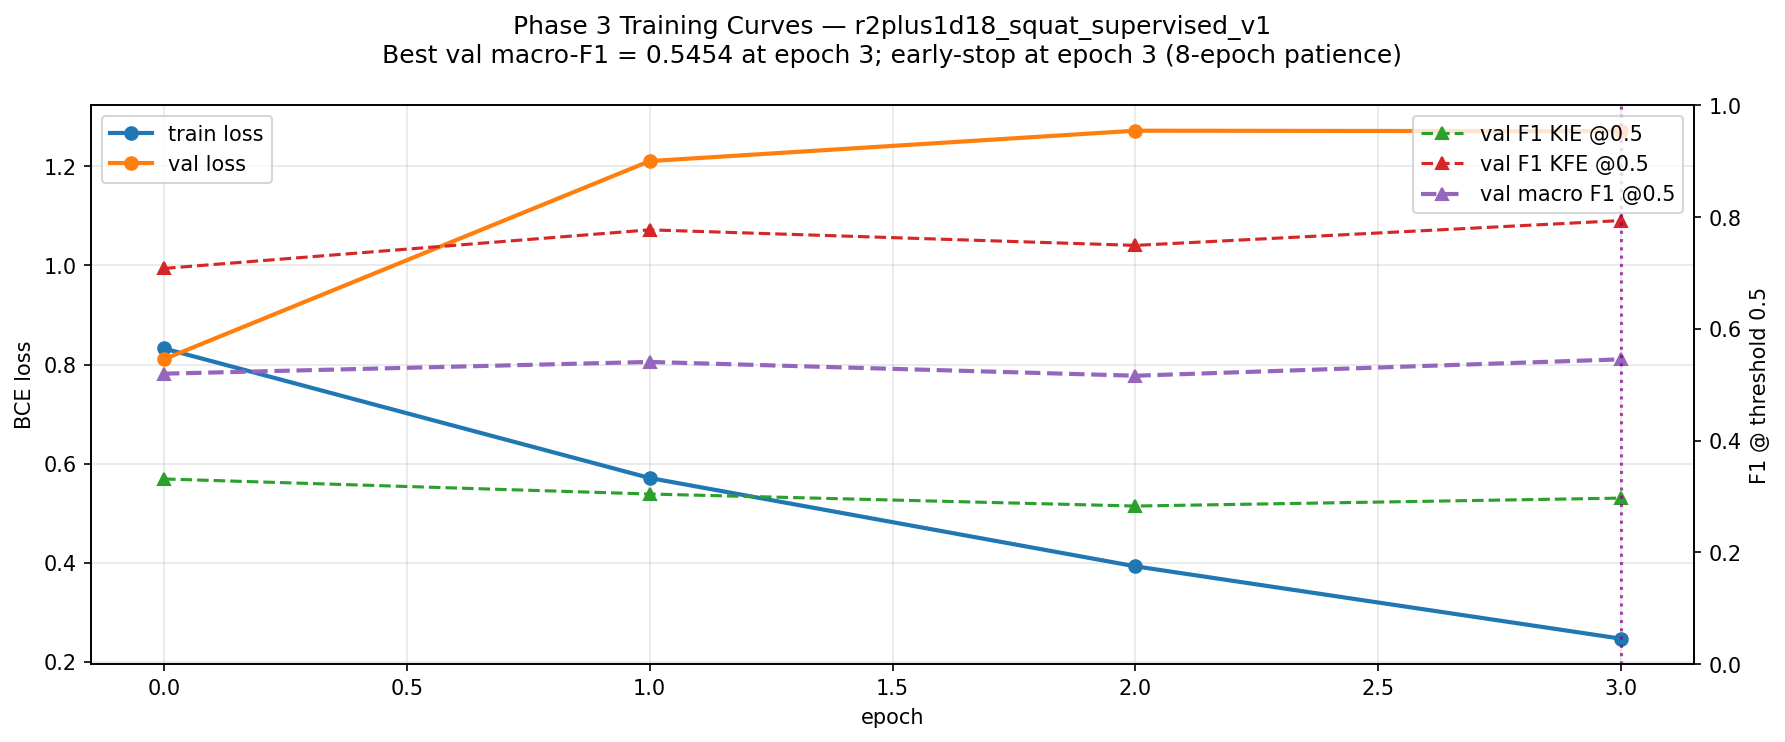

  saved: confusion_kie.png  (32.7 KB)


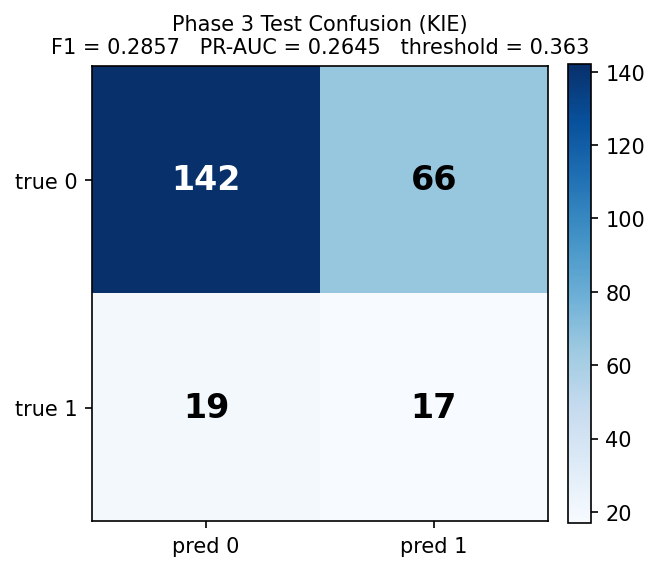

  saved: confusion_kfe.png  (31.5 KB)


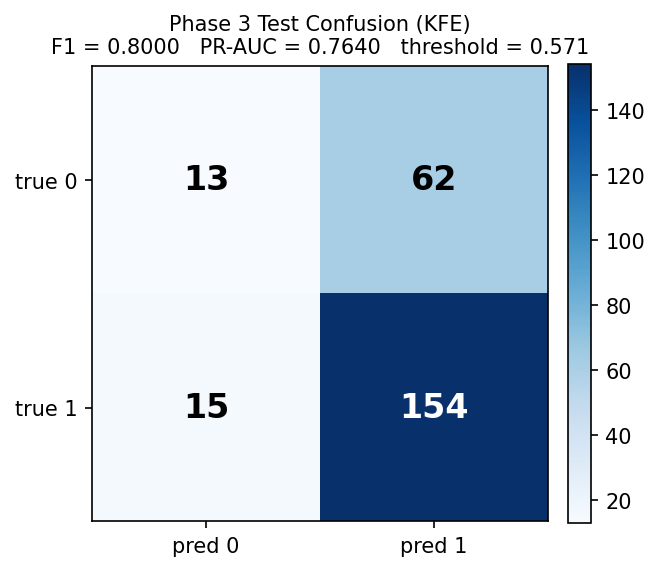

  saved: pr_kie.png  (56.9 KB)


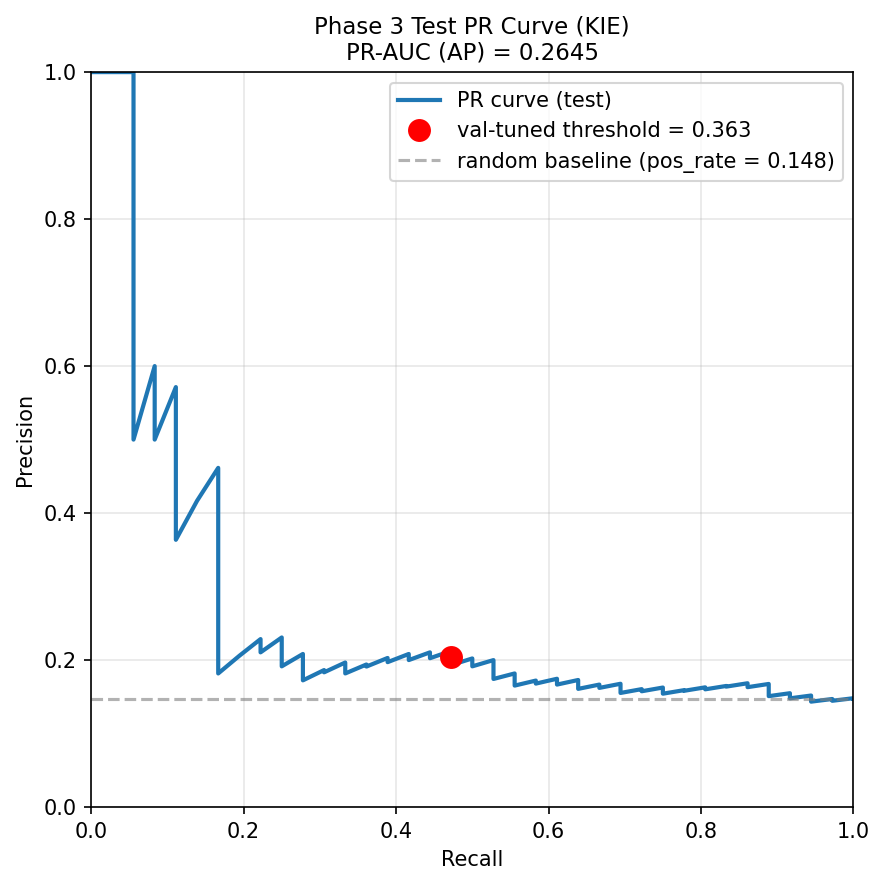

  saved: pr_kfe.png  (58.7 KB)


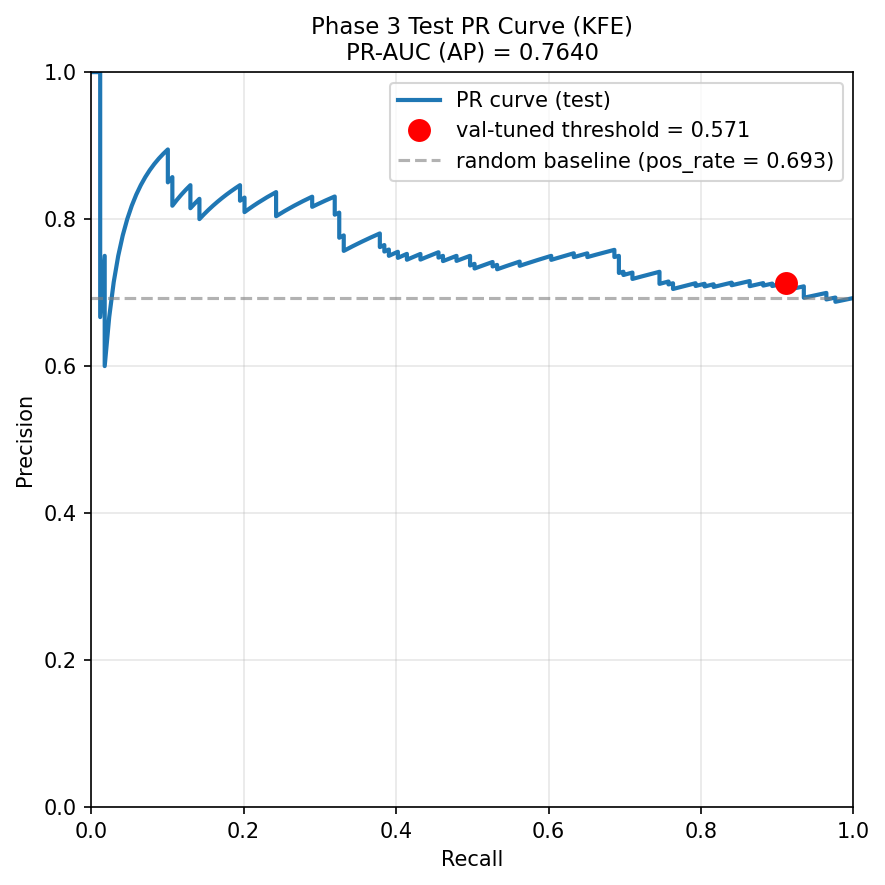


Mapped 244 test clip_ids to video paths.
  saved: sample_predictions_kie.png  (1130.2 KB)


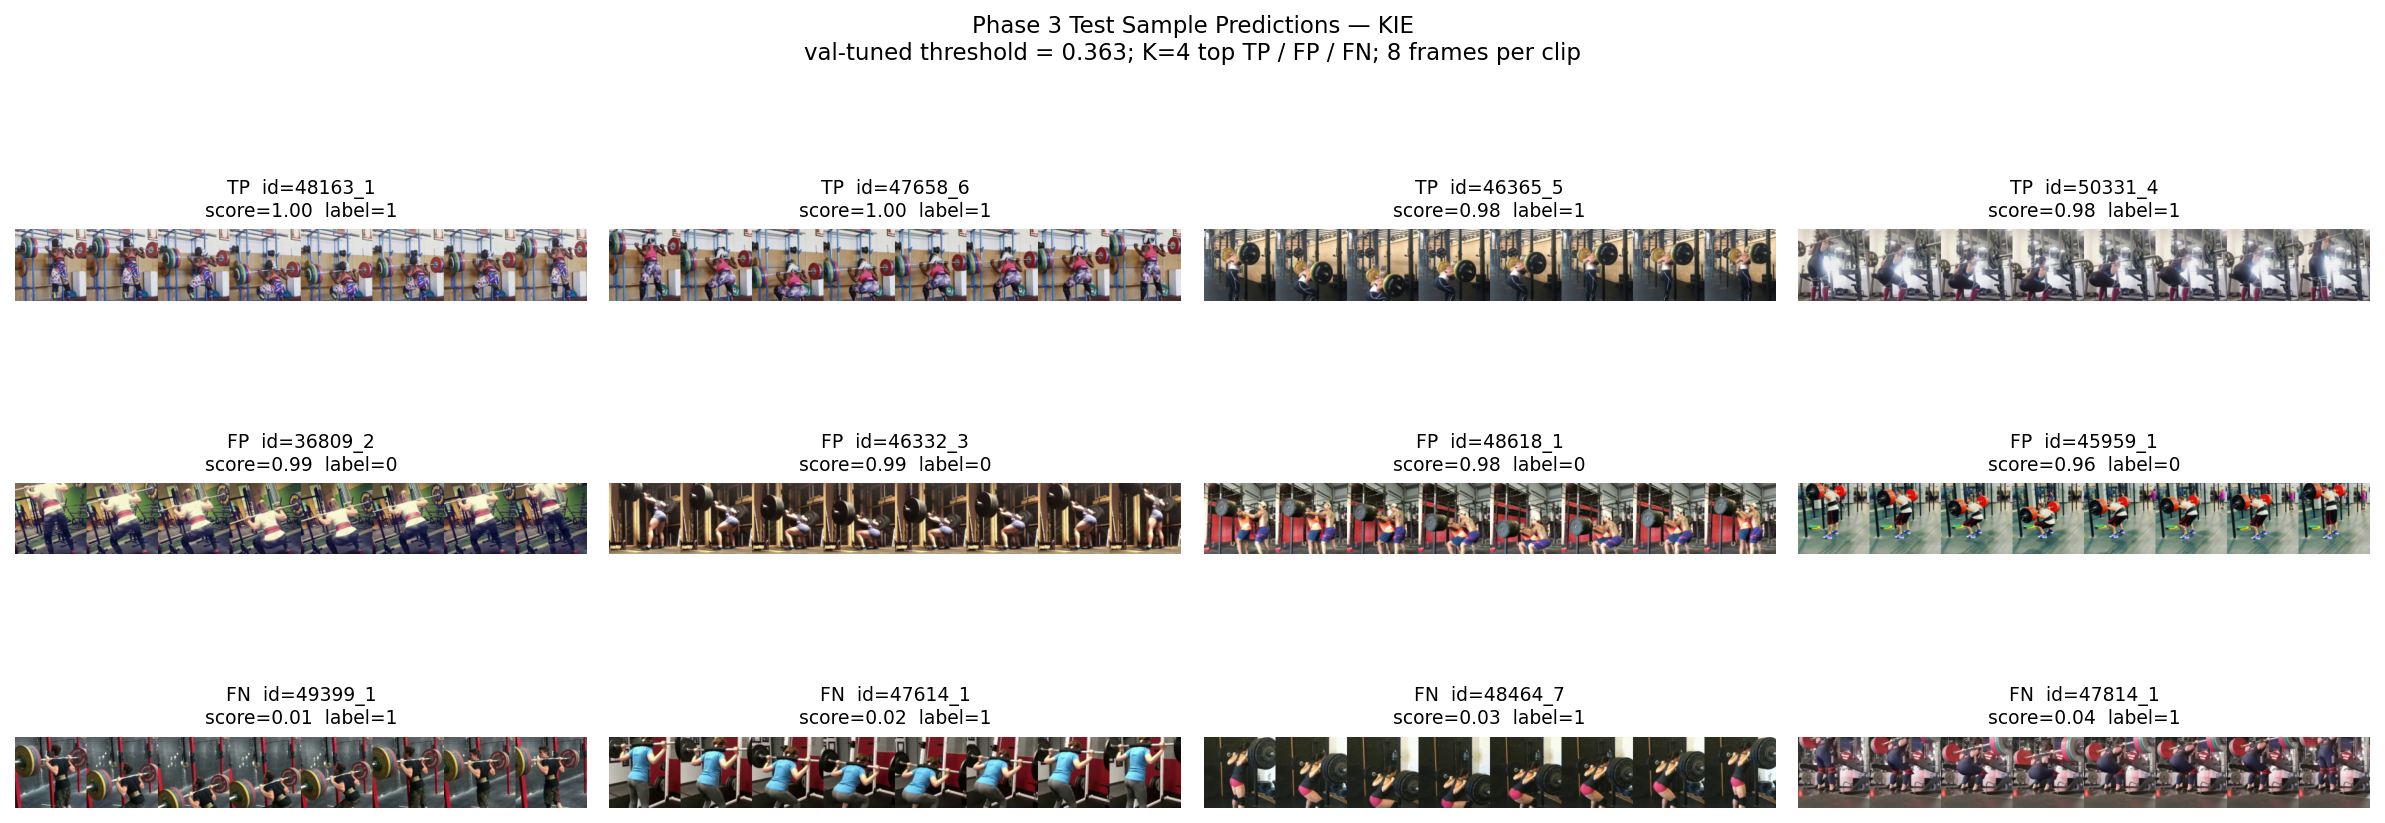

  saved: sample_predictions_kfe.png  (1133.4 KB)


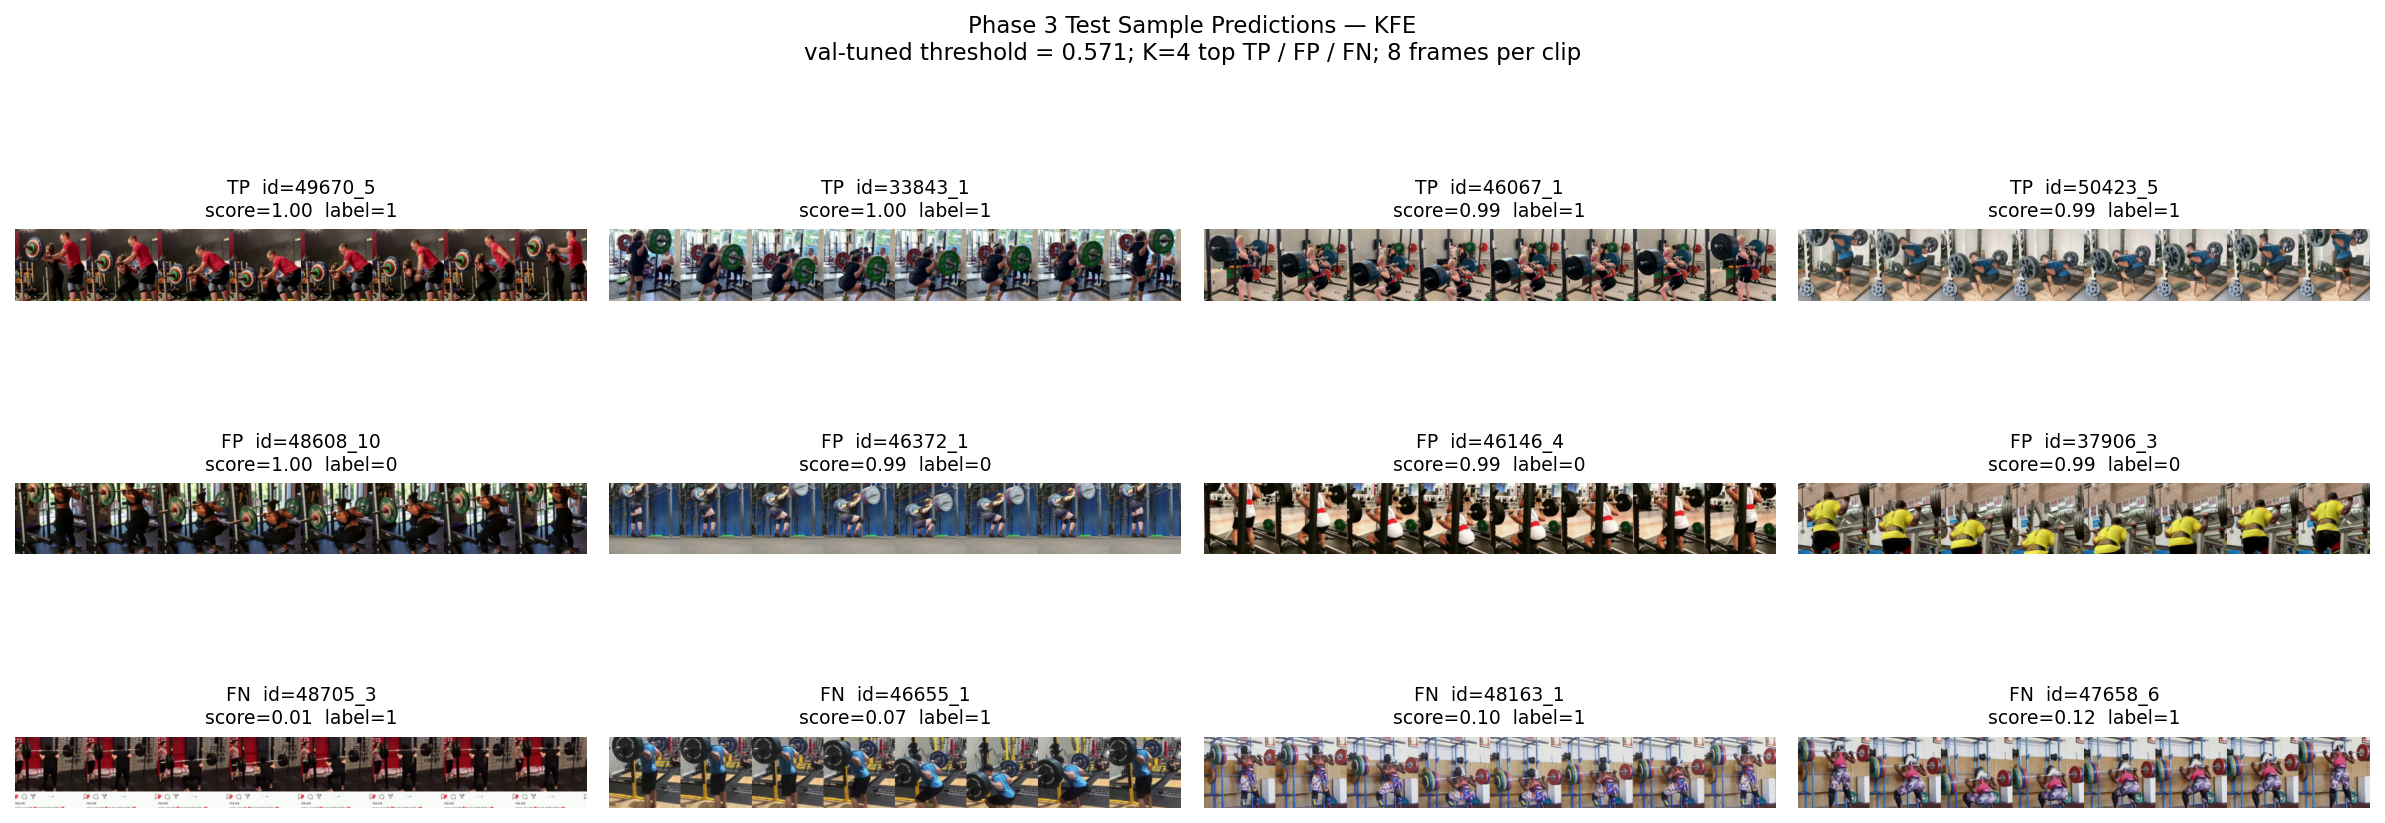


7 figures backed up to Drive: /content/drive/MyDrive/FitNova/checkpoints/phase03/r2plus1d18_squat_supervised_v1/figures

Step 7 complete — Phase 3 deliverables on disk: results.pkl + 7 PNGs + best.pt on Drive.
Next: Task 15 (you eye-check the figures) + Task 16 (SUMMARY.md closeout).


In [ ]:
import os
import pickle
import shutil
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torchvision.io
from sklearn.metrics import precision_recall_curve

from backend.training.aqa.datasets import splits as splits_mod
from backend.training.aqa.datasets.transforms import (
    KINETICS_MEAN,
    KINETICS_STD,
    decode_clip,
    spatial_val,
    uniform_sample_indices,
)

FIG_DIR = Path("docs/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_PATH = FIG_DIR / "results.pkl"
with RESULTS_PATH.open("rb") as f:
    R = pickle.load(f)
print(f"Loaded results.pkl: best_epoch={R['best_epoch']}, run={R['run_name']}")


def save_show(fig, name):
    out = FIG_DIR / name
    out.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(out, dpi=150, bbox_inches="tight")
    print(f"  saved: {out.name}  ({out.stat().st_size / 1024:.1f} KB)")
    plt.show()
    plt.close(fig)


# Fig 1: training curves
mh = R["metrics_history"]
epochs = [e["epoch"] for e in mh]
best_idx = max(range(len(mh)), key=lambda i: mh[i]["val_macro_f1"])
best_epoch = epochs[best_idx]

fig, ax1 = plt.subplots(figsize=(12, 5), dpi=150)
ax1.plot(epochs, [e["train_loss_mean"] for e in mh], "-o", color="tab:blue", label="train loss", linewidth=2)
ax1.plot(epochs, [e["val_loss_mean"] for e in mh], "-o", color="tab:orange", label="val loss", linewidth=2)
ax1.set_xlabel("epoch"); ax1.set_ylabel("BCE loss")
ax1.grid(alpha=0.3); ax1.legend(loc="upper left")
ax2 = ax1.twinx()
ax2.plot(epochs, [e["val_f1_kie"] for e in mh], "--^", color="tab:green", label="val F1 KIE @0.5")
ax2.plot(epochs, [e["val_f1_kfe"] for e in mh], "--^", color="tab:red", label="val F1 KFE @0.5")
ax2.plot(epochs, [e["val_macro_f1"] for e in mh], "--^", color="tab:purple", label="val macro F1 @0.5", linewidth=2)
ax2.axvline(x=best_epoch, color="purple", linestyle=":", alpha=0.7)
ax2.set_ylabel("F1 @ threshold 0.5"); ax2.set_ylim(0, 1); ax2.legend(loc="upper right")
fig.suptitle(
    f"Training Curves — {R['run_name']}\n"
    f"Best val macro-F1 = {mh[best_idx]['val_macro_f1']:.4f} at epoch {best_epoch}; "
    f"early-stop at epoch {epochs[-1]} (8-epoch patience)"
)
fig.tight_layout()
save_show(fig, "training_curves.png")


# Fig 2 + 3: confusion matrices
def plot_confusion(cm, err_name, f1, pr_auc, thresh, name):
    fig, ax = plt.subplots(figsize=(4.5, 4.5), dpi=150)
    im = ax.imshow(cm, cmap="Blues", aspect="equal")
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f"{int(cm[i, j])}", ha="center", va="center", fontsize=16, fontweight="bold",
                    color="white" if cm[i, j] > cm.max() / 2 else "black")
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(["pred 0", "pred 1"]); ax.set_yticklabels(["true 0", "true 1"])
    ax.set_title(f"Test Confusion ({err_name})\nF1 = {f1:.4f}   PR-AUC = {pr_auc:.4f}   threshold = {thresh:.3f}", fontsize=10)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    fig.tight_layout()
    save_show(fig, name)

plot_confusion(R["test_confusion_kie"], "KIE", R["test_f1_kie"], R["test_pr_auc_kie"], R["val_thresholds"]["kie"], "confusion_kie.png")
plot_confusion(R["test_confusion_kfe"], "KFE", R["test_f1_kfe"], R["test_pr_auc_kfe"], R["val_thresholds"]["kfe"], "confusion_kfe.png")


# Fig 4 + 5: PR curves
def plot_pr(y_true, y_score, err_name, ap, thresh, name):
    p, r, thresholds = precision_recall_curve(y_true, y_score)
    fig, ax = plt.subplots(figsize=(6, 6), dpi=150)
    ax.plot(r, p, "-", color="tab:blue", linewidth=2, label="PR curve (test)")
    if len(thresholds) > 0:
        idx = int(np.argmin(np.abs(thresholds - thresh)))
        ax.plot(r[idx], p[idx], "ro", markersize=10, label=f"val-tuned threshold = {thresh:.3f}")
    pos_rate = float(np.mean(y_true))
    ax.axhline(y=pos_rate, color="gray", linestyle="--", alpha=0.6, label=f"random baseline (pos_rate = {pos_rate:.3f})")
    ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.legend(loc="best"); ax.grid(alpha=0.3)
    ax.set_title(f"Test PR Curve ({err_name})\nPR-AUC (AP) = {ap:.4f}", fontsize=11)
    fig.tight_layout()
    save_show(fig, name)

plot_pr(R["test_labels"][:, 0], R["test_scores"][:, 0], "KIE", R["test_pr_auc_kie"], R["val_thresholds"]["kie"], "pr_kie.png")
plot_pr(R["test_labels"][:, 1], R["test_scores"][:, 1], "KFE", R["test_pr_auc_kfe"], R["val_thresholds"]["kfe"], "pr_kfe.png")


# Fig 6 + 7: sample-prediction grids per error
test_records = splits_mod.index("test", drive_root=MYDRIVE, videos_root=VIDEOS_ROOT)
clip_id_to_path = {r.clip_id: r.video_path for r in test_records}
print(f"\nMapped {len(clip_id_to_path)} test clip_ids to video paths.")

_MEAN_T = torch.tensor(KINETICS_MEAN).view(1, 3, 1, 1)
_STD_T = torch.tensor(KINETICS_STD).view(1, 3, 1, 1)


def render_clip_strip(clip_id, n_frames=8):
    path = clip_id_to_path[clip_id]
    pts_list, _ = torchvision.io.read_video_timestamps(path, pts_unit="sec")
    indices = uniform_sample_indices(len(pts_list), target=n_frames)
    clip_tchw = decode_clip(path, indices)
    clip_cthw = spatial_val(clip_tchw, crop_size=112)
    clip_tchw_f = clip_cthw.permute(1, 0, 2, 3).contiguous()
    clip_tchw_f = (clip_tchw_f * _STD_T + _MEAN_T).clamp(0, 1)
    frames_hwc = clip_tchw_f.permute(0, 2, 3, 1).numpy()
    return np.concatenate(frames_hwc, axis=1)


def plot_sample_predictions(err_idx, err_name, top_k=4, name=""):
    scores = R["test_scores"][:, err_idx]
    labels = R["test_labels"][:, err_idx]
    clip_ids = R["test_clip_ids"]
    threshold = R["val_thresholds"][err_name.lower()]

    pos_idx = np.where(labels == 1)[0]
    neg_idx = np.where(labels == 0)[0]
    tp_top = pos_idx[np.argsort(-scores[pos_idx])[:top_k]]
    fp_top = neg_idx[np.argsort(-scores[neg_idx])[:top_k]]
    fn_top = pos_idx[np.argsort(scores[pos_idx])[:top_k]]

    groups = [("TP", tp_top), ("FP", fp_top), ("FN", fn_top)]
    fig, axes = plt.subplots(3, top_k, figsize=(16, 6.5), dpi=150)
    for row_idx, (gname, indices) in enumerate(groups):
        for col_idx in range(top_k):
            ax = axes[row_idx, col_idx]
            if col_idx >= len(indices):
                ax.axis("off"); continue
            i = int(indices[col_idx])
            clip_id = clip_ids[i]
            score = float(scores[i]); label = int(labels[i])
            try:
                strip = render_clip_strip(clip_id)
                ax.imshow(strip)
            except Exception as exc:
                ax.text(0.5, 0.5, f"unavailable\n{clip_id}\n{type(exc).__name__}",
                        ha="center", va="center", transform=ax.transAxes, fontsize=8, color="red")
            ax.set_title(f"{gname}  id={clip_id}\nscore={score:.2f}  label={label}", fontsize=9)
            ax.axis("off")
    fig.suptitle(f"Test Sample Predictions — {err_name}\nval-tuned threshold = {threshold:.3f}; K={top_k} top TP / FP / FN; 8 frames per clip", fontsize=11)
    fig.tight_layout()
    save_show(fig, name)

plot_sample_predictions(0, "KIE", top_k=4, name="sample_predictions_kie.png")
plot_sample_predictions(1, "KFE", top_k=4, name="sample_predictions_kfe.png")


# Drive backup
drive_fig_dir = os.path.join(MYDRIVE, "FitNova/checkpoints/phase03/r2plus1d18_squat_supervised_v1/figures")
os.makedirs(drive_fig_dir, exist_ok=True)
fig_names = ["training_curves.png", "confusion_kie.png", "confusion_kfe.png",
             "pr_kie.png", "pr_kfe.png",
             "sample_predictions_kie.png", "sample_predictions_kfe.png"]
for fn in fig_names:
    shutil.copy2(str(FIG_DIR / fn), os.path.join(drive_fig_dir, fn))
print(f"\n{len(fig_names)} figures backed up to Drive: {drive_fig_dir}")
print("\nStep 7 complete — outputs on disk: results.pkl + 7 PNGs + best.pt on Drive.")
print("Next: review the figures.")

Loaded epoch_011.pt: full metrics_history has 12 epochs
results.pkl had 4 epochs; patching to 12
results.pkl patched: /content/fitnova/.planning/phases/03-squat-supervised-baseline/figures/results.pkl
results.pkl drive backup updated.

Re-rendered: /content/fitnova/.planning/phases/03-squat-supervised-baseline/figures/training_curves.png  (143.3 KB)
Drive backup updated: /content/drive/MyDrive/FitNova/checkpoints/phase03/r2plus1d18_squat_supervised_v1/figures/training_curves.png


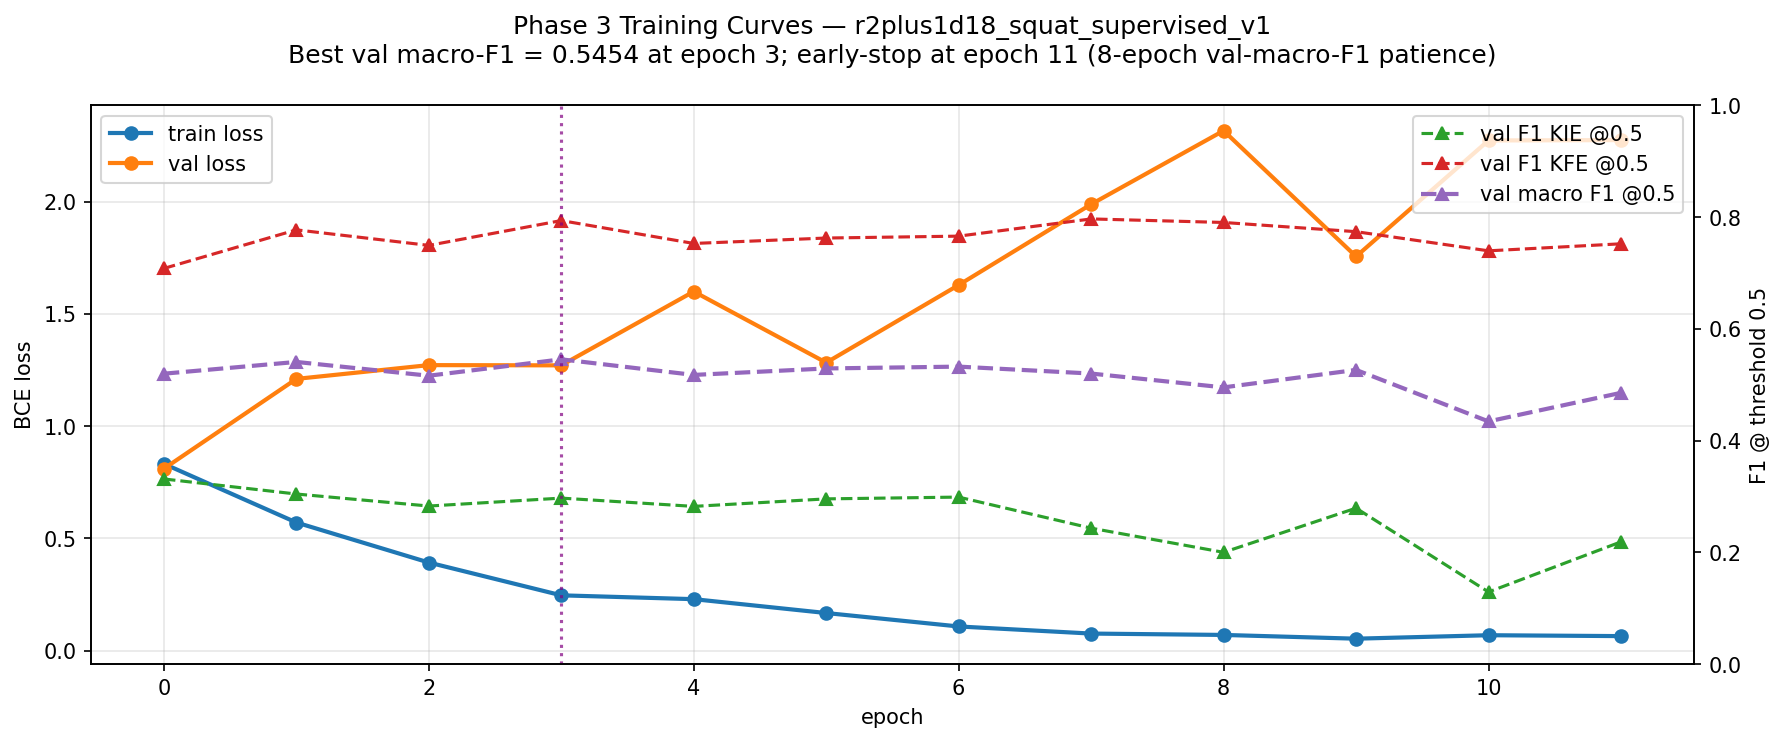

In [ ]:
import os
import pickle
from pathlib import Path

import matplotlib.pyplot as plt
import torch

RUN_NAME = "r2plus1d18_squat_supervised_v1"
run_dir = os.path.join(MYDRIVE, "FitNova/checkpoints/phase03", RUN_NAME)
FIG_DIR = Path("docs/figures")
RESULTS_PATH = FIG_DIR / "results.pkl"

# Load latest.txt-pointed checkpoint (has full 12-epoch metrics_history)
with open(os.path.join(run_dir, "latest.txt"), "r", encoding="utf-8") as f:
    latest_name = f.read().strip()
latest_payload = torch.load(
    os.path.join(run_dir, latest_name), map_location="cpu", weights_only=False,
)
full_mh = latest_payload["metrics_history"]
print(f"Loaded {latest_name}: full metrics_history has {len(full_mh)} epochs")

# Patch results.pkl
with RESULTS_PATH.open("rb") as f:
    R = pickle.load(f)
print(f"results.pkl had {len(R['metrics_history'])} epochs; patching to {len(full_mh)}")
R["metrics_history"] = full_mh
R["final_epoch"] = latest_payload["epoch"]
with RESULTS_PATH.open("wb") as f:
    pickle.dump(R, f)
print(f"results.pkl patched: {RESULTS_PATH}")

# Drive backup of patched results.pkl
import shutil
shutil.copy2(str(RESULTS_PATH), os.path.join(run_dir, "results.pkl"))
print(f"results.pkl drive backup updated.")

# Re-render training_curves.png with FULL history
epochs = [e["epoch"] for e in full_mh]
best_idx = max(range(len(full_mh)), key=lambda i: full_mh[i]["val_macro_f1"])
best_epoch = epochs[best_idx]

fig, ax1 = plt.subplots(figsize=(12, 5), dpi=150)
ax1.plot(epochs, [e["train_loss_mean"] for e in full_mh], "-o", color="tab:blue", label="train loss", linewidth=2)
ax1.plot(epochs, [e["val_loss_mean"] for e in full_mh], "-o", color="tab:orange", label="val loss", linewidth=2)
ax1.set_xlabel("epoch"); ax1.set_ylabel("BCE loss")
ax1.grid(alpha=0.3); ax1.legend(loc="upper left")
ax2 = ax1.twinx()
ax2.plot(epochs, [e["val_f1_kie"] for e in full_mh], "--^", color="tab:green", label="val F1 KIE @0.5")
ax2.plot(epochs, [e["val_f1_kfe"] for e in full_mh], "--^", color="tab:red", label="val F1 KFE @0.5")
ax2.plot(epochs, [e["val_macro_f1"] for e in full_mh], "--^", color="tab:purple", label="val macro F1 @0.5", linewidth=2)
ax2.axvline(x=best_epoch, color="purple", linestyle=":", alpha=0.7)
ax2.set_ylabel("F1 @ threshold 0.5"); ax2.set_ylim(0, 1); ax2.legend(loc="upper right")
fig.suptitle(
    f"Training Curves — {RUN_NAME}\n"
    f"Best val macro-F1 = {full_mh[best_idx]['val_macro_f1']:.4f} at epoch {best_epoch}; "
    f"early-stop at epoch {epochs[-1]} (8-epoch val-macro-F1 patience)"
)
fig.tight_layout()

out = FIG_DIR / "training_curves.png"
fig.savefig(out, dpi=150, bbox_inches="tight")
print(f"\nRe-rendered: {out}  ({out.stat().st_size / 1024:.1f} KB)")

# Drive backup the corrected figure
drive_fig_dir = os.path.join(run_dir, "figures")
shutil.copy2(str(out), os.path.join(drive_fig_dir, "training_curves.png"))
print(f"Drive backup updated: {drive_fig_dir}/training_curves.png")

plt.show()
plt.close(fig)